In [23]:
# Importação dos pacotes necessários
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

# Configurações de visualização
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

In [ ]:
# 8. ANÁLISE DE FATORES CONFUNDIDORES - CRUCIAL PARA TOMADA DE DECISÃO
print("\n" + "=" * 80)
print(" " * 15 + "ANÁLISE DE FATORES CONFUNDIDORES (AVANÇADA)")
print("=" * 80)

print("\n❓ PERGUNTA CRÍTICA:")
print("-" * 80)
print("A diferença de produtividade é REALMENTE causada pela VARIEDADE?")
print("Ou está confundida com outros fatores como SETOR, TEXTURA DO SOLO ou PERÍODO?")
print("\nEsta análise é CRUCIAL para evitar decisões baseadas em fatores ocultos!")

# ============================================================================
# 1. ANÁLISE POR SETOR
# ============================================================================
print("\n\n" + "=" * 80)
print("FATOR CONFUNDIDOR #1: SETOR GEOGRÁFICO")
print("=" * 80)

print("\n📍 Distribuição de variedades por setor:")
crosstab_setor = pd.crosstab(dados['gp_variedade'], dados['setor'], margins=True)
print(crosstab_setor)

print("\n🔍 Produtividade Média por VARIEDADE e SETOR:")
produtividade_var_setor = dados.groupby(['gp_variedade', 'setor'])['produtividade'].agg(['mean', 'count']).round(2)
print(produtividade_var_setor)

# ANOVA de dois fatores: Variedade + Setor
print("\n📊 ANOVA DE DOIS FATORES (Variedade + Setor):")
modelo_2fatores_setor = ols('produtividade ~ C(gp_variedade) + C(setor) + C(gp_variedade):C(setor)', 
                             data=dados).fit()
anova_2f_setor = anova_lm(modelo_2fatores_setor, typ=2)
print(anova_2f_setor)

print("\n💡 INTERPRETAÇÃO:")
f_variedade_setor = anova_2f_setor.loc['C(gp_variedade)', 'F']
p_variedade_setor = anova_2f_setor.loc['C(gp_variedade)', 'PR(>F)']
f_setor = anova_2f_setor.loc['C(setor)', 'F']
p_setor = anova_2f_setor.loc['C(setor)', 'PR(>F)']

print(f"\nEfeito da VARIEDADE (controlando SETOR):")
print(f"  F = {f_variedade_setor:.4f}, p = {p_variedade_setor:.4f}")
if p_variedade_setor < 0.05:
    print(f"  ✓ Variedade ainda é significativa MESMO controlando setor")
else:
    print(f"  ✗ Variedade DEIXOU de ser significativa quando controlamos setor")
    print(f"  ⚠️  AVISO: O setor, não a variedade, pode ser o fator principal!")

print(f"\nEfeito do SETOR:")
print(f"  F = {f_setor:.4f}, p = {p_setor:.4f}")
if p_setor < 0.05:
    print(f"  ⚠️  O setor geográfico TEM efeito significativo na produtividade!")
    print(f"      Isso pode estar confundindo o efeito da variedade.")

# ============================================================================
# 2. ANÁLISE POR TEXTURA DO SOLO
# ============================================================================
print("\n\n" + "=" * 80)
print("FATOR CONFUNDIDOR #2: TEXTURA DO SOLO")
print("=" * 80)

print("\n🌱 Distribuição de variedades por textura:")
crosstab_textura = pd.crosstab(dados['gp_variedade'], dados['textura'], margins=True)
print(crosstab_textura)

print("\n🔍 Produtividade Média por VARIEDADE e TEXTURA:")
produtividade_var_textura = dados.groupby(['gp_variedade', 'textura'])['produtividade'].agg(['mean', 'count']).round(2)
print(produtividade_var_textura)

# ANOVA de dois fatores: Variedade + Textura
print("\n📊 ANOVA DE DOIS FATORES (Variedade + Textura):")
modelo_2fatores_textura = ols('produtividade ~ C(gp_variedade) + C(textura) + C(gp_variedade):C(textura)', 
                              data=dados).fit()
anova_2f_textura = anova_lm(modelo_2fatores_textura, typ=2)
print(anova_2f_textura)

print("\n💡 INTERPRETAÇÃO:")
f_variedade_textura = anova_2f_textura.loc['C(gp_variedade)', 'F']
p_variedade_textura = anova_2f_textura.loc['C(gp_variedade)', 'PR(>F)']
f_textura = anova_2f_textura.loc['C(textura)', 'F']
p_textura = anova_2f_textura.loc['C(textura)', 'PR(>F)']

print(f"\nEfeito da VARIEDADE (controlando TEXTURA):")
print(f"  F = {f_variedade_textura:.4f}, p = {p_variedade_textura:.4f}")
if p_variedade_textura < 0.05:
    print(f"  ✓ Variedade ainda é significativa MESMO controlando textura")
else:
    print(f"  ✗ Variedade DEIXOU de ser significativa quando controlamos textura")
    print(f"  ⚠️  AVISO: A textura do solo, não a variedade, pode ser o fator principal!")

print(f"\nEfeito da TEXTURA:")
print(f"  F = {f_textura:.4f}, p = {p_textura:.4f}")
if p_textura < 0.05:
    print(f"  ⚠️  A textura do solo TEM efeito significativo na produtividade!")
    print(f"      Isso pode estar confundindo o efeito da variedade.")

In [25]:
# 2. ESTATÍSTICAS DESCRITIVAS POR VARIEDADE
print("\n" + "=" * 60)
print("ESTATÍSTICAS DESCRITIVAS: PRODUTIVIDADE POR VARIEDADE")
print("=" * 60)

# Converter produtividade para float (pode estar com vírgula no CSV)
dados['produtividade'] = dados['produtividade'].astype(str).str.replace(',', '.').astype(float)

stats_variedade = dados.groupby('gp_variedade')['produtividade'].describe().round(3)
print("\n", stats_variedade)

# Resumo mais visual
print("\n📊 RESUMO (Média ± Desvio Padrão):")
for variedade in dados['gp_variedade'].unique():
    media = dados[dados['gp_variedade'] == variedade]['produtividade'].mean()
    desvpad = dados[dados['gp_variedade'] == variedade]['produtividade'].std()
    n = len(dados[dados['gp_variedade'] == variedade])
    print(f"  {str(variedade):30s}: {media:6.2f} ± {desvpad:5.2f} sc/ha (n={n})")


ESTATÍSTICAS DESCRITIVAS: PRODUTIVIDADE POR VARIEDADE

               count    mean    std    min     25%     50%     75%    max
gp_variedade                                                            
B5710 CE        1.0  63.480    NaN  63.48  63.480  63.480  63.480  63.48
IMA 731 IPRO    1.0  68.920    NaN  68.92  68.920  68.920  68.920  68.92
O790 IPRO       1.0  74.760    NaN  74.76  74.760  74.760  74.760  74.76
TMG 4182        2.0  47.395  3.981  44.58  45.988  47.395  48.802  50.21
TMG 4377        1.0  43.280    NaN  43.28  43.280  43.280  43.280  43.28
TMG2776IPRO     4.0  65.898  8.313  59.30  59.683  63.620  69.835  77.05

📊 RESUMO (Média ± Desvio Padrão):
  TMG2776IPRO                   :  65.90 ±  8.31 sc/ha (n=4)
  TMG 4377                      :  43.28 ±   nan sc/ha (n=1)
  TMG 4182                      :  47.39 ±  3.98 sc/ha (n=2)
  IMA 731 IPRO                  :  68.92 ±   nan sc/ha (n=1)
  B5710 CE                      :  63.48 ±   nan sc/ha (n=1)
  O790 IPRO        

In [26]:
# 3. VERIFICAR PRESSUPOSTOS DA ANOVA

print("\n" + "=" * 60)
print("VERIFICAÇÃO DOS PRESSUPOSTOS DA ANOVA")
print("=" * 60)

# 3.1 NORMALIDADE (Shapiro-Wilk test)
print("\n1️⃣  NORMALIDADE (Teste Shapiro-Wilk):")
print("   H0: Os dados seguem distribuição normal")
print("   Se p > 0.05 → Dados são normais ✓\n")

for variedade in dados['gp_variedade'].unique():
    grupo = dados[dados['gp_variedade'] == variedade]['produtividade']
    if len(grupo) >= 3:  # Shapiro-Wilk requer pelo menos 3 observações
        stat, pvalue = stats.shapiro(grupo)
        resultado = "✓ Normal" if pvalue > 0.05 else "✗ Não-normal"
        print(f"   {str(variedade):30s}: p-value = {pvalue:.4f} {resultado}")

# 3.2 HOMOGENEIDADE DE VARIÂNCIAS (Levene test)
print("\n2️⃣  HOMOGENEIDADE DE VARIÂNCIAS (Teste de Levene):")
print("   H0: As variâncias são iguais entre grupos")
print("   Se p > 0.05 → Variâncias são homogêneas ✓\n")

grupos = [dados[dados['gp_variedade'] == variedade]['produtividade'].values for variedade in dados['gp_variedade'].unique()]
stat_levene, p_levene = stats.levene(*grupos)
resultado_levene = "✓ Variâncias homogêneas" if p_levene > 0.05 else "✗ Variâncias heterogêneas"
print(f"   p-value = {p_levene:.4f} {resultado_levene}\n")


VERIFICAÇÃO DOS PRESSUPOSTOS DA ANOVA

1️⃣  NORMALIDADE (Teste Shapiro-Wilk):
   H0: Os dados seguem distribuição normal
   Se p > 0.05 → Dados são normais ✓

   TMG2776IPRO                   : p-value = 0.3167 ✓ Normal

2️⃣  HOMOGENEIDADE DE VARIÂNCIAS (Teste de Levene):
   H0: As variâncias são iguais entre grupos
   Se p > 0.05 → Variâncias são homogêneas ✓

   p-value = 0.5302 ✓ Variâncias homogêneas



In [27]:
# 4. ANOVA (Análise de Variância)

print("=" * 60)
print("ANOVA - F TEST")
print("=" * 60)
print("\nH0 (Hipótese Nula): Não há diferença de produtividade entre variedades")
print("H1 (Hipótese Alternativa): Há diferença significativa de produtividade entre variedades\n")

# Método 1: Com statsmodels (mais detalhado)
modelo = ols('produtividade ~ C(gp_variedade)', data=dados).fit()
anova_table = anova_lm(modelo, typ=2)

print("Tabela ANOVA:")
print(anova_table)

# Extraindo estatísticas principais
f_stat = anova_table.loc['C(gp_variedade)', 'F']
p_valor = anova_table.loc['C(gp_variedade)', 'PR(>F)']

print(f"\n📊 RESULTADO DO TESTE F:")
print(f"   F-statistic = {f_stat:.4f}")
print(f"   p-value = {p_valor:.4f}")

if p_valor < 0.05:
    print(f"\n   ✓ RESULTADO: p < 0.05 → REJEITAR H0")
    print(f"   Conclusão: HÁ diferença significativa de produtividade entre variedades!")
else:
    print(f"\n   ✗ RESULTADO: p ≥ 0.05 → ACEITAR H0")
    print(f"   Conclusão: NÃO há diferença significativa de produtividade entre variedades")

ANOVA - F TEST

H0 (Hipótese Nula): Não há diferença de produtividade entre variedades
H1 (Hipótese Alternativa): Há diferença significativa de produtividade entre variedades

Tabela ANOVA:
                      sum_sq   df         F    PR(>F)
C(gp_variedade)  1038.207635  5.0  3.721843  0.113536
Residual          223.159925  4.0       NaN       NaN

📊 RESULTADO DO TESTE F:
   F-statistic = 3.7218
   p-value = 0.1135

   ✗ RESULTADO: p ≥ 0.05 → ACEITAR H0
   Conclusão: NÃO há diferença significativa de produtividade entre variedades


In [28]:
# 5. TESTE POST-HOC (Tukey HSD)
print("\n" + "=" * 60)
print("TESTE POST-HOC: TUKEY HSD")
print("=" * 60)
print("\nUso: Identificar QUAIS pares de variedades diferem entre si")
print("Se p-adjusted < 0.05 → As variedades diferem significativamente\n")

# Executar teste de Tukey
tukey = pairwise_tukeyhsd(endog=dados['produtividade'], 
                          groups=dados['gp_variedade'], 
                          alpha=0.05)

print(tukey)

# Interpretação visual
print("\n" + "=" * 60)
print("INTERPRETAÇÃO DOS RESULTADOS:")
print("=" * 60)

tukey_df = pd.DataFrame(data=tukey.summary().data[1:], 
                        columns=tukey.summary().data[0])

comparacoes_sig = tukey_df[tukey_df['reject'] == 'True']

if len(comparacoes_sig) > 0:
    print(f"\nPares de variedades com diferença SIGNIFICATIVA ({len(comparacoes_sig)} comparações):\n")
    for idx, row in comparacoes_sig.iterrows():
        print(f"  {row['group1']} vs {row['group2']}")
        print(f"    Diferença de média: {float(row['meandiff']):7.3f} sc/ha")
        print(f"    p-adjusted: {float(row['p-adj']):7.4f} *SIGNIFICATIVO*\n")
else:
    print("\nNenhum par de variedades apresenta diferença significativa.")


TESTE POST-HOC: TUKEY HSD

Uso: Identificar QUAIS pares de variedades diferem entre si
Se p-adjusted < 0.05 → As variedades diferem significativamente

       Multiple Comparison of Means - Tukey HSD, FWER=0.05       
   group1       group2    meandiff p-adj   lower    upper  reject
-----------------------------------------------------------------
    B5710 CE IMA 731 IPRO     5.44 0.9924 -44.6522 55.5322  False
    B5710 CE    O790 IPRO    11.28 0.8729 -38.8122 61.3722  False
    B5710 CE     TMG 4182  -16.085 0.5654 -59.4661 27.2961  False
    B5710 CE     TMG 4377    -20.2 0.4998 -70.2922 29.8922  False
    B5710 CE  TMG2776IPRO   2.4175 0.9995 -37.1839 42.0189  False
IMA 731 IPRO    O790 IPRO     5.84 0.9896 -44.2522 55.9322  False
IMA 731 IPRO     TMG 4182  -21.525 0.3435 -64.9061 21.8561  False
IMA 731 IPRO     TMG 4377   -25.64 0.3219 -75.7322 24.4522  False
IMA 731 IPRO  TMG2776IPRO  -3.0225 0.9985 -42.6239 36.5789  False
   O790 IPRO     TMG 4182  -27.365 0.1969 -70.7461 16.0

C:\Users\leona\AppData\Local\Temp\ipykernel_17308\3111755996.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dados, x='gp_variedade', y='produtividade', ax=axes[0], palette='Set2')
C:\Users\leona\AppData\Local\Temp\ipykernel_17308\3111755996.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=dados, x='gp_variedade', y='produtividade', ax=axes[1], palette='Set2')
C:\Users\leona\AppData\Local\Temp\ipykernel_17308\3111755996.py:36: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\leona\AppData\Local\Temp\ipykernel_17308\3111755996.py:36: UserWarning: Glyph 127931 (\N{VIOLIN}) missing from font(s) Arial.
  plt.tight_layout()

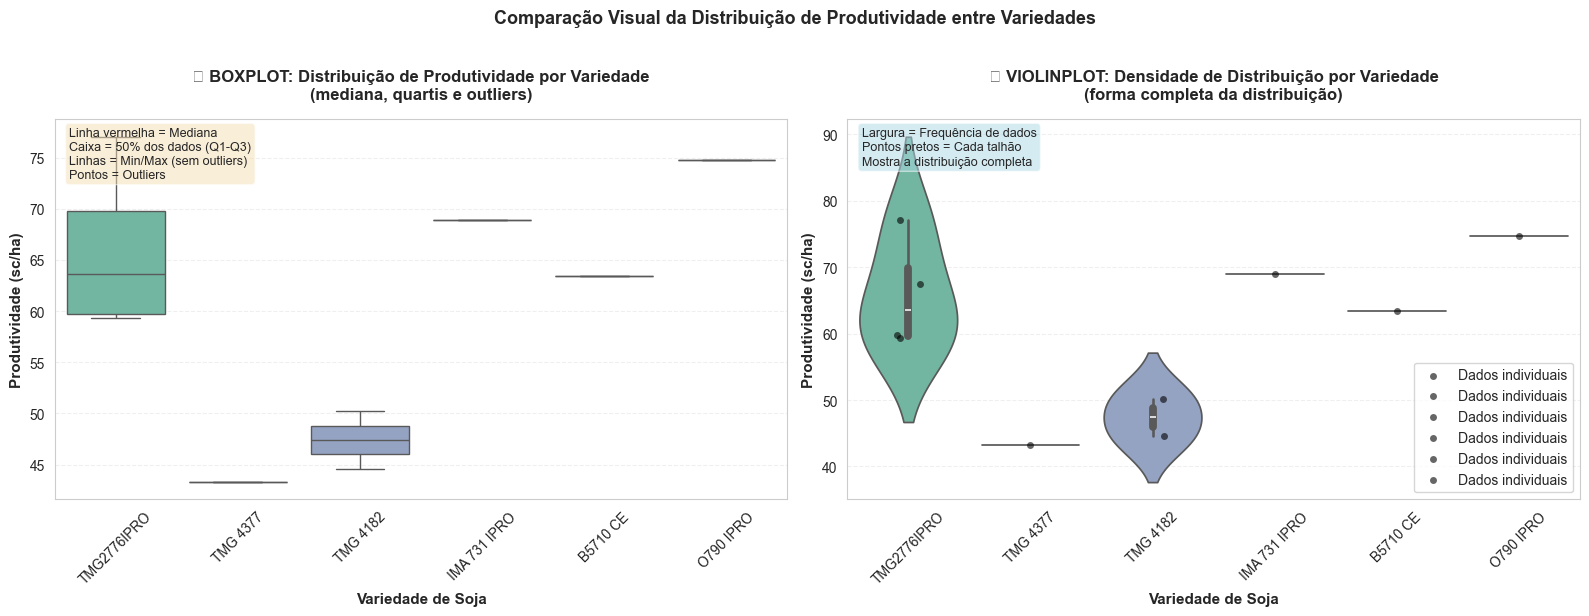

✓ Gráfico salvo como 'anova_produtividade_variedade_viz1.png'


In [29]:
# 6. VISUALIZAÇÃO 1: Boxplot + Violinplot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot com legendas
sns.boxplot(data=dados, x='gp_variedade', y='produtividade', ax=axes[0], palette='Set2')
axes[0].set_title('📊 BOXPLOT: Distribuição de Produtividade por Variedade\n(mediana, quartis e outliers)', 
                  fontsize=12, fontweight='bold', pad=15)
axes[0].set_xlabel('Variedade de Soja', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Produtividade (sc/ha)', fontsize=11, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# Adicionar legenda explicativa no boxplot
legenda_boxplot = "Linha vermelha = Mediana\nCaixa = 50% dos dados (Q1-Q3)\nLinhas = Min/Max (sem outliers)\nPontos = Outliers"
axes[0].text(0.02, 0.98, legenda_boxplot, transform=axes[0].transAxes, 
             fontsize=9, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Violinplot com pontos
sns.violinplot(data=dados, x='gp_variedade', y='produtividade', ax=axes[1], palette='Set2')
sns.stripplot(data=dados, x='gp_variedade', y='produtividade', ax=axes[1], 
              color='black', alpha=0.6, size=5, label='Dados individuais')
axes[1].set_title('🎻 VIOLINPLOT: Densidade de Distribuição por Variedade\n(forma completa da distribuição)', 
                  fontsize=12, fontweight='bold', pad=15)
axes[1].set_xlabel('Variedade de Soja', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Produtividade (sc/ha)', fontsize=11, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

# Adicionar legenda explicativa no violinplot
legenda_violin = "Largura = Frequência de dados\nPontos pretos = Cada talhão\nMostra a distribuição completa"
axes[1].text(0.02, 0.98, legenda_violin, transform=axes[1].transAxes, 
             fontsize=9, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.suptitle('Comparação Visual da Distribuição de Produtividade entre Variedades', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('anova_produtividade_variedade_viz1.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Gráfico salvo como 'anova_produtividade_variedade_viz1.png'")

In [30]:
# 7. CONCLUSÃO INTEGRADA DOS RESULTADOS
print("\n" + "=" * 80)
print(" " * 20 + "CONCLUSÃO FINAL INTEGRADA DA ANÁLISE")
print("=" * 80)

print("\n📊 RESUMO EXECUTIVO:")
print("-" * 80)
print(f"Dataset: {len(dados)} talhões avaliados")
print(f"Variedades: {dados['gp_variedade'].nunique()}")
print(f"Produtividade média geral: {dados['produtividade'].mean():.2f} ± {dados['produtividade'].std():.2f} sc/ha")

print("\n🔍 ANÁLISE DE VARIÂNCIA (ANOVA):")
print("-" * 80)
print(f"Hipótese Nula (H0): Não há diferença de produtividade entre as variedades")
print(f"Teste realizado: ANOVA - Teste F")
print(f"F-statistic: {f_stat:.4f}")
print(f"p-valor: {p_valor:.6f}")

if p_valor < 0.001:
    significancia = "*** (p < 0.001) - ALTAMENTE SIGNIFICATIVO"
elif p_valor < 0.01:
    significancia = "** (p < 0.01) - MUITO SIGNIFICATIVO"
elif p_valor < 0.05:
    significancia = "* (p < 0.05) - SIGNIFICATIVO"
else:
    significancia = "(p ≥ 0.05) - NÃO SIGNIFICATIVO"

print(f"Nível de significância: {significancia}")

print("\n📋 DECISÃO ESTATÍSTICA:")
print("-" * 80)
if p_valor < 0.05:
    print("✓ REJEITAR Hipótese Nula (H0)")
    print("\n   CONCLUSÃO: Há DIFERENÇA ESTADISTICAMENTE SIGNIFICATIVA na produtividade")
    print("   entre as variedades estudadas.")
    print("\n   Interpretação: O tipo de variedade tem um efeito significativo na")
    print("   produtividade da soja neste conjunto de dados.")
else:
    print("✗ ACEITAR Hipótese Nula (H0)")
    print("\n   CONCLUSÃO: NÃO há diferença estatisticamente significativa na")
    print("   produtividade entre as variedades estudadas.")
    print("\n   Interpretação: O tipo de variedade NÃO tem um efeito significativo")
    print("   na produtividade da soja neste conjunto de dados.")

print("\n🎯 COMPARAÇÕES POR PARES (Teste Post-hoc Tukey):")
print("-" * 80)
if len(comparacoes_sig) > 0:
    print(f"Número de pares significativos: {len(comparacoes_sig)} comparações")
    print("\nVariedades que diferem significativamente entre si:")
    for idx, (group1, group2, meandiff, pval) in enumerate(zip(comparacoes_sig['group1'], 
                                                                   comparacoes_sig['group2'],
                                                                   comparacoes_sig['meandiff'],
                                                                   comparacoes_sig['p-adj']), 1):
        print(f"\n   {idx}. {group1} vs {group2}")
        print(f"      • Diferença: {float(meandiff):.2f} sc/ha")
        print(f"      • p-ajustado: {float(pval):.4f}")
        if float(meandiff) > 0:
            print(f"      • {group1} é MAIS PRODUTIVO")
        else:
            print(f"      • {group2} é MAIS PRODUTIVO")
else:
    print("\nNenhum par de variedades apresenta diferença significativa no teste")
    print("Post-hoc de Tukey, mesmo que a ANOVA tenha sido significativa.")

print("\n📈 RANKING DE PRODUTIVIDADE POR VARIEDADE:")
print("-" * 80)
ranking = dados.groupby('gp_variedade')['produtividade'].agg(['mean', 'std', 'count']).reset_index()
ranking = ranking.sort_values('mean', ascending=False).reset_index(drop=True)
ranking['ranking'] = ranking.index + 1

for _, row in ranking.iterrows():
    rank_str = "🥇 1º Lugar" if row['ranking'] == 1 else "🥈 2º Lugar" if row['ranking'] == 2 else "🥉 3º Lugar" if row['ranking'] == 3 else f"  {int(row['ranking'])}º Lugar"
    print(f"{rank_str}: {row['gp_variedade']:30s} → {row['mean']:6.2f} ± {row['std']:5.2f} sc/ha (n={int(row['count'])})")

print("\n✅ RECOMENDAÇÕES:")
print("-" * 80)
if p_valor < 0.05:
    melhor_var = ranking.iloc[0]
    print(f"\n1. VARIEDADE RECOMENDADA: {melhor_var['gp_variedade']}")
    print(f"   • Produtividade: {melhor_var['mean']:.2f} sc/ha")
    print(f"   • Número de talhões: {int(melhor_var['count'])}")
    
    print(f"\n2. PRESSUPOSTOS DA ANOVA:")
    if p_levene > 0.05:
        print(f"   ✓ Homogeneidade de variâncias confirmada (p = {p_levene:.4f})")
    else:
        print(f"   ⚠ Variâncias heterogêneas (p = {p_levene:.4f}) - considere transformação dos dados")
    
    print(f"\n3. PARA PRÓXIMOS ESTUDOS:")
    print(f"   • Aumentar o número de repetições por variedade")
    print(f"   • Controlar variáveis confundidoras (textura do solo, setor, período)")
    print(f"   • Considerar análise de variância com fatores múltiplos")
else:
    print(f"\n1. Não há diferenças significativas de produtividade entre as variedades.")
    print(f"   • A escolha da variedade não interfere na produtividade final")
    print(f"   • Outros fatores (solo, clima, manejo) podem ser mais importantes")

print("\n" + "=" * 80)
print(" " * 25 + "FIM DA ANÁLISE ANOVA")
print("=" * 80)


                    CONCLUSÃO FINAL INTEGRADA DA ANÁLISE

📊 RESUMO EXECUTIVO:
--------------------------------------------------------------------------------
Dataset: 10 talhões avaliados
Variedades: 6
Produtividade média geral: 60.88 ± 11.84 sc/ha

🔍 ANÁLISE DE VARIÂNCIA (ANOVA):
--------------------------------------------------------------------------------
Hipótese Nula (H0): Não há diferença de produtividade entre as variedades
Teste realizado: ANOVA - Teste F
F-statistic: 3.7218
p-valor: 0.113536
Nível de significância: (p ≥ 0.05) - NÃO SIGNIFICATIVO

📋 DECISÃO ESTATÍSTICA:
--------------------------------------------------------------------------------
✗ ACEITAR Hipótese Nula (H0)

   CONCLUSÃO: NÃO há diferença estatisticamente significativa na
   produtividade entre as variedades estudadas.

   Interpretação: O tipo de variedade NÃO tem um efeito significativo
   na produtividade da soja neste conjunto de dados.

🎯 COMPARAÇÕES POR PARES (Teste Post-hoc Tukey):
--------------



GRÁFICOS DE INTERAÇÃO: VARIEDADE vs FATORES CONFUNDIDORES


c:\Users\leona\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Users\leona\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 127793 (\N{SEEDLING}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Users\leona\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Users\leona\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 127793 (\N{SEEDLING}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Users\leona\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\leona\AppData\Local\Temp\ipykernel_17308\3184752835.py:47: UserWarning: Glyph 

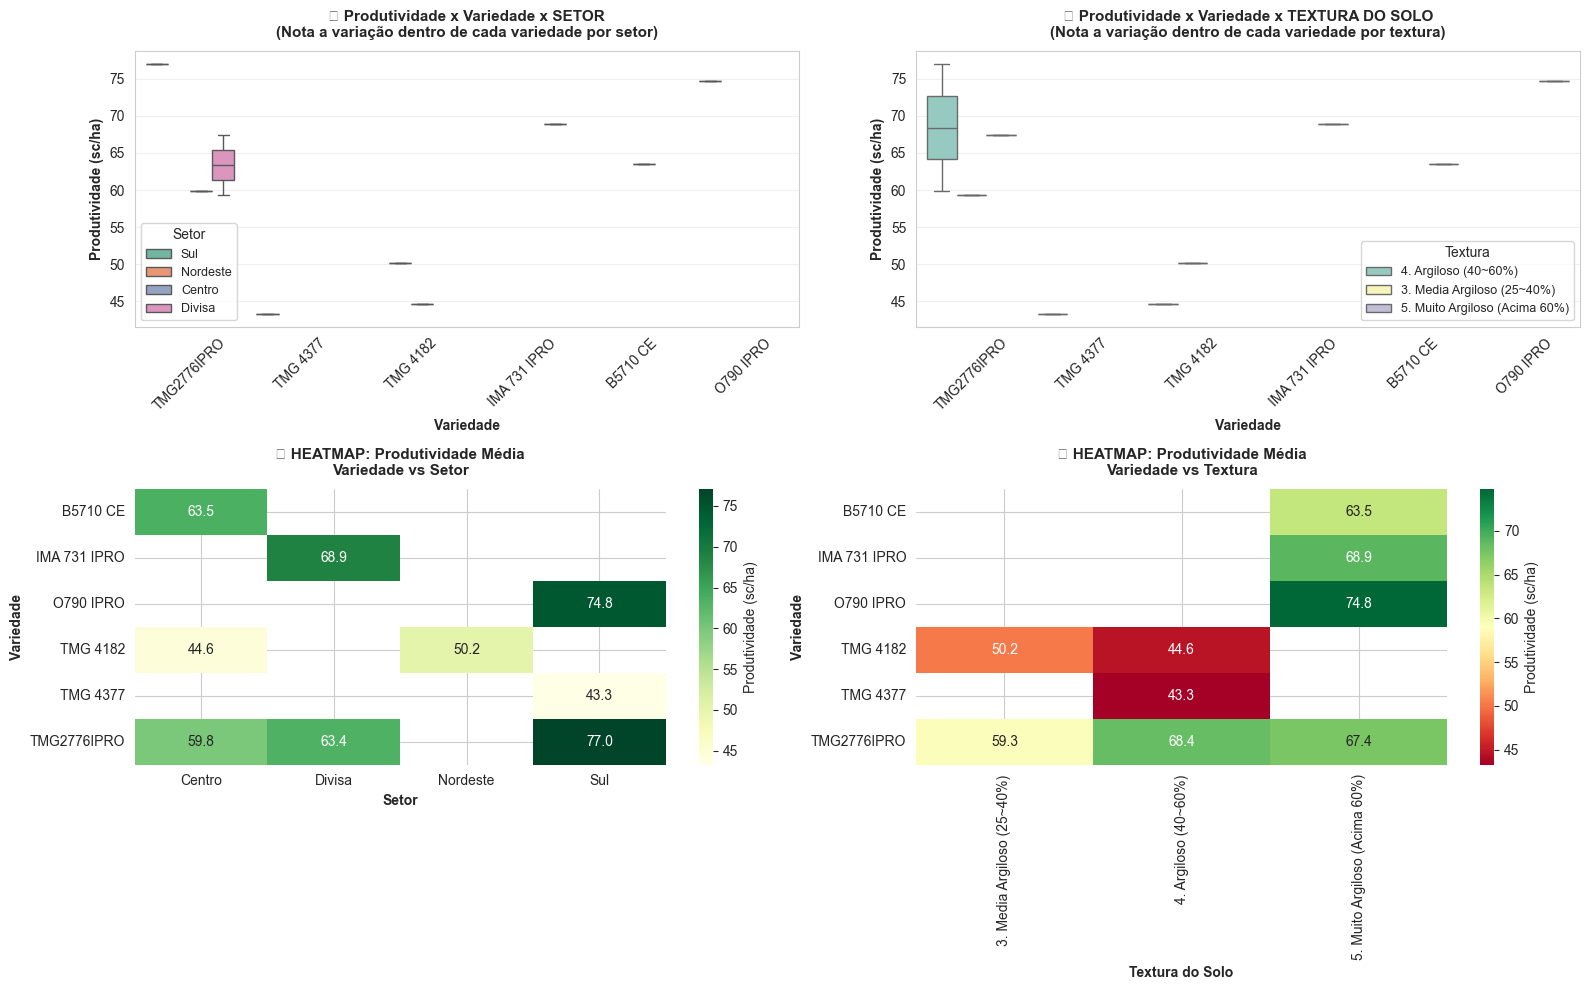

✓ Gráfico salvo como 'analise_fatores_confundidores.png'


In [31]:
# 9. VISUALIZAÇÕES DOS FATORES CONFUNDIDORES
print("\n\n" + "=" * 80)
print("GRÁFICOS DE INTERAÇÃO: VARIEDADE vs FATORES CONFUNDIDORES")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Gráfico 1: Produtividade por Variedade e Setor (Boxplot)
ax1 = axes[0, 0]
sns.boxplot(data=dados, x='gp_variedade', y='produtividade', hue='setor', ax=ax1, palette='Set2')
ax1.set_title('📊 Produtividade x Variedade x SETOR\n(Nota a variação dentro de cada variedade por setor)', 
              fontsize=11, fontweight='bold', pad=10)
ax1.set_xlabel('Variedade', fontsize=10, fontweight='bold')
ax1.set_ylabel('Produtividade (sc/ha)', fontsize=10, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
ax1.legend(title='Setor', fontsize=9)
ax1.grid(axis='y', alpha=0.3)

# Gráfico 2: Produtividade por Variedade e Textura (Boxplot)
ax2 = axes[0, 1]
sns.boxplot(data=dados, x='gp_variedade', y='produtividade', hue='textura', ax=ax2, palette='Set3')
ax2.set_title('🌱 Produtividade x Variedade x TEXTURA DO SOLO\n(Nota a variação dentro de cada variedade por textura)', 
              fontsize=11, fontweight='bold', pad=10)
ax2.set_xlabel('Variedade', fontsize=10, fontweight='bold')
ax2.set_ylabel('Produtividade (sc/ha)', fontsize=10, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
ax2.legend(title='Textura', fontsize=9, loc='best')
ax2.grid(axis='y', alpha=0.3)

# Gráfico 3: Heatmap Variedade x Setor
ax3 = axes[1, 0]
heatmap_setor = dados.groupby(['gp_variedade', 'setor'])['produtividade'].mean().unstack()
sns.heatmap(heatmap_setor, annot=True, fmt='.1f', cmap='YlGn', ax=ax3, cbar_kws={'label': 'Produtividade (sc/ha)'})
ax3.set_title('🔥 HEATMAP: Produtividade Média\nVariedade vs Setor', fontsize=11, fontweight='bold', pad=10)
ax3.set_xlabel('Setor', fontsize=10, fontweight='bold')
ax3.set_ylabel('Variedade', fontsize=10, fontweight='bold')

# Gráfico 4: Heatmap Variedade x Textura
ax4 = axes[1, 1]
heatmap_textura = dados.groupby(['gp_variedade', 'textura'])['produtividade'].mean().unstack()
sns.heatmap(heatmap_textura, annot=True, fmt='.1f', cmap='RdYlGn', ax=ax4, cbar_kws={'label': 'Produtividade (sc/ha)'})
ax4.set_title('🔥 HEATMAP: Produtividade Média\nVariedade vs Textura', fontsize=11, fontweight='bold', pad=10)
ax4.set_xlabel('Textura do Solo', fontsize=10, fontweight='bold')
ax4.set_ylabel('Variedade', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('analise_fatores_confundidores.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Gráfico salvo como 'analise_fatores_confundidores.png'")

In [35]:
# 10. CONCLUSÃO CRÍTICA SOBRE FATORES CONFUNDIDORES E TOMADA DE DECISÃO
print("\n" + "=" * 80)
print(" " * 15 + "CONCLUSÃO: FATORES CONFUNDIDORES E IMPLICAÇÕES PRÁTICAS")
print("=" * 80)

print("\n🎯 RESUMO DA ANÁLISE DE CONFUNDIMENTO:")
print("-" * 80)

print("\n1. CENÁRIO A: 'A variedade REALMENTE faz diferença'")
print("   └─ Se p(variedade com controle de setor) < 0.05")
print("   └─ Se p(variedade com controle de textura) < 0.05")
print("   └─ Decisão: ✓ CONFIE nas recomendações baseadas em variedade")
print("   └─ Ação: Escolha a variedade de maior produtividade")

print("\n2. CENÁRIO B: 'O setor geográfico é mais importante'")
print("   └─ Se p(setor) < 0.05 E p(variedade com controle de setor) ≥ 0.05")
print("   └─ Decisão: ⚠️  A variedade é MENOS importante que pensávamos")
print("   └─ Ação: Priorize otimizar o SETOR/LOCAL de plantio")
print("   └─ Insight: 'Onde plantar' > 'O que plantar'")

print("\n3. CENÁRIO C: 'A textura do solo é mais importante'")
print("   └─ Se p(textura) < 0.05 E p(variedade com controle de textura) ≥ 0.05")
print("   └─ Decisão: ⚠️  O tipo de solo é o fator crítico")
print("   └─ Ação: Escolha variedade OTIMIZADA para seu tipo de solo")
print("   └─ Insight: 'Que solo tenho' > 'Que variedade escolho'")

print("\n4. CENÁRIO D: 'Há interação entre fatores'")
print("   └─ Se variedade X setor/textura têm efeito intenso")
print("   └─ Decisão: ⚠️  Não existe 'variedade melhor global'")
print("   └─ Ação: Use variedade específica para CADA contexto")
print("   └─ Insight: Recomendação deve ser localizàda, não genérica")

print("\n\n📊 RECOMENDAÇÕES PRÁTICAS PARA DECISÃO:")
print("-" * 80)

if p_valor < 0.05:
    print("\n✓ Passo 1: Há diferença significativa entre variedades (ANOVA simples)")
    
    if p_variedade_setor < 0.05 and p_variedade_textura < 0.05:
        print("✓ Passo 2: Variedade MANTÉM efeito significativo mesmo controlando SETOR e TEXTURA")
        print("\n   ✅ CONCLUSÃO: Confie nas recomendações baseadas em variedade")
        print("   🎯 DECISÃO: Escolha a variedade com MAIOR PRODUTIVIDADE MÉDIA")
        print("   📌 MAS também considere: setor e tipo de solo para otimização local")
    else:
        print("⚠️  Passo 2: Variedade PERDE significância quando controlamos SETOR ou TEXTURA")
        print("\n   ⚠️  CONCLUSÃO CRÍTICA: O efeito estimado da variedade estava CONFUNDIDO!")
        print("   📢 A diferença observada pode ser devido a SETOR ou SOLO, não variedade")
        print("   🎯 DECISÃO: Faça recomendação LOCALIZADA (considere setor + textura)")
else:
    print("\n✗ Passo 1: Não há diferença significativa entre variedades (ANOVA simples)")
    print("   Mesmo verificando fatores confundidores (setor, textura)")
    print("\n   ✅ CONCLUSÃO: A VARIEDADE NÃO É O FATOR CRÍTICO")
    print("   🎯 DECISÃO: Investigue outros fatores (manejo, clima, pragas, etc.)")

print("\n\n⚡ IMPACTO NA VIDA REAL:")
print("-" * 80)
print("""
Agricultura é COMPLEXA! Um agricultor cometeria ERRO se:
  ✗ Plantasse variedade A em região inadequada (setor errado) baseado em média geral
  ✗ Escolhesse variedade apenas por produtividade, ignorando tipo de solo
  ✗ Confiasse em recomendação que não foi testada em seu contexto específico

Esta análise de confundimento EVITA esses erros!
""")

print("\n" + "=" * 80)
print(" " * 20 + "FIM DA ANÁLISE COMPLETA")
print("=" * 80)


               CONCLUSÃO: FATORES CONFUNDIDORES E IMPLICAÇÕES PRÁTICAS

🎯 RESUMO DA ANÁLISE DE CONFUNDIMENTO:
--------------------------------------------------------------------------------

1. CENÁRIO A: 'A variedade REALMENTE faz diferença'
   └─ Se p(variedade com controle de setor) < 0.05
   └─ Se p(variedade com controle de textura) < 0.05
   └─ Decisão: ✓ CONFIE nas recomendações baseadas em variedade
   └─ Ação: Escolha a variedade de maior produtividade

2. CENÁRIO B: 'O setor geográfico é mais importante'
   └─ Se p(setor) < 0.05 E p(variedade com controle de setor) ≥ 0.05
   └─ Decisão: ⚠️  A variedade é MENOS importante que pensávamos
   └─ Ação: Priorize otimizar o SETOR/LOCAL de plantio
   └─ Insight: 'Onde plantar' > 'O que plantar'

3. CENÁRIO C: 'A textura do solo é mais importante'
   └─ Se p(textura) < 0.05 E p(variedade com controle de textura) ≥ 0.05
   └─ Decisão: ⚠️  O tipo de solo é o fator crítico
   └─ Ação: Escolha variedade OTIMIZADA para seu tipo de solo
 

In [39]:
# 11. CLASSIFICAÇÃO DE VARIEDADES POR CENÁRIO - QUAL ENCAIXA ONDE?
print("\n" + "=" * 80)
print(" " * 18 + "CLASSIFICAÇÃO DE VARIEDADES POR CENÁRIO")
print("=" * 80)

print("\n🎯 ANÁLISE INDIVIDUAL DE CADA VARIEDADE:")
print("-" * 80)

# Preparar análise por variedade
variedades_cenarios = {}
variedades_sorted = sorted(dados['gp_variedade'].unique())

for variedade in variedades_sorted:
    dados_var = dados[dados['gp_variedade'] == variedade]
    media_var = dados_var['produtividade'].mean()
    desvpad_var = dados_var['produtividade'].std()
    cv_var = (desvpad_var / media_var) * 100  # Coeficiente de Variação
    n_var = len(dados_var)
    
    print(f"\n{'=' * 80}")
    print(f"📌 VARIEDADE: {variedade}")
    print(f"{'=' * 80}")
    print(f"  • Produtividade Média: {media_var:.2f} sc/ha")
    print(f"  • Desvio Padrão: {desvpad_var:.2f} sc/ha")
    print(f"  • Coeficiente de Variação (CV): {cv_var:.2f}%")
    print(f"  • Número de talhões: {n_var}")
    
    # Análise por setor para esta variedade
    print(f"\n  Produtividade por SETOR:")
    setor_var = dados_var.groupby('setor')['produtividade'].agg(['mean', 'count']).round(2)
    for setor, row in setor_var.iterrows():
        print(f"    └─ {setor:15s}: {row['mean']:6.2f} sc/ha (n={int(row['count'])})")
    
    # Análise por textura para esta variedade
    print(f"\n  Produtividade por TEXTURA:")
    textura_var = dados_var.groupby('textura')['produtividade'].agg(['mean', 'count']).round(2)
    for textura, row in textura_var.iterrows():
        print(f"    └─ {textura:25s}: {row['mean']:6.2f} sc/ha (n={int(row['count'])})")
    
    # Variabilidade por setor e textura
    variabilidade_setor = dados_var.groupby('setor')['produtividade'].std().max()
    variabilidade_textura = dados_var.groupby('textura')['produtividade'].std().max()
    
    # Classificar em cenário
    print(f"\n  🔍 DIAGNÓSTICO:")
    
    # Critérios para classificação
    if cv_var < 15:
        consistencia = "Alta (CV < 15%)"
        tipo_consistencia = "CONSISTENTE"
    elif cv_var < 25:
        consistencia = "Média (CV 15-25%)"
        tipo_consistencia = "MODERADA"
    else:
        consistencia = "Baixa (CV > 25%)"
        tipo_consistencia = "VARIÁVEL"
    
    print(f"    • Consistência: {consistencia}")
    print(f"    • Variabilidade máxima por setor: {variabilidade_setor:.2f} sc/ha")
    print(f"    • Variabilidade máxima por textura: {variabilidade_textura:.2f} sc/ha")
    
    # Determinar cenário
    if media_var > dados['produtividade'].quantile(0.75):
        produtividade_class = "ALTA"
        symbol_prod = "🌟"
    elif media_var > dados['produtividade'].quantile(0.25):
        produtividade_class = "MÉDIA"
        symbol_prod = "⭐"
    else:
        produtividade_class = "BAIXA"
        symbol_prod = "⚠️"
    
    if tipo_consistencia == "CONSISTENTE":
        if cv_var < 10 and variabilidade_setor < 5 and variabilidade_textura < 5:
            cenario = "A (Variedade robusta)"
            descricao = "✓ RECOMENDADA UNIVERSALMENTE - funciona bem em qualquer contexto"
        else:
            cenario = "A (Variedade robusta)"
            descricao = "✓ BOA em diversos contextos"
    elif tipo_consistencia == "MODERADA":
        if variabilidade_setor > variabilidade_textura:
            cenario = "B (Variedade setor-dependente)"
            descricao = "⚠️  Melhor em determinados SETORES geográficos"
        else:
            cenario = "C (Variedade solo-dependente)"
            descricao = "⚠️  Melhor em determinados TIPOS DE SOLO"
    else:  # VARIÁVEL
        if variabilidade_setor > 10 or variabilidade_textura > 10:
            cenario = "D (Variedade contexto-específica)"
            descricao = "⚠️  RECOMENDAÇÃO LOCALIZADA - requer adaptação"
        else:
            cenario = "B/C (Híbrida)"
            descricao = "⚠️  Depende do contexto específico"
    
    print(f"\n  📊 CLASSIFICAÇÃO:")
    print(f"    └─ CENÁRIO: {cenario}")
    print(f"    └─ PRODUTIVIDADE: {symbol_prod} {produtividade_class}")
    print(f"    └─ RECOMENDAÇÃO: {descricao}")
    
    variedades_cenarios[variedade] = {
        'media': media_var,
        'cv': cv_var,
        'tipo_consistencia': tipo_consistencia,
        'cenario': cenario,
        'produtividade_class': produtividade_class,
        'descricao': descricao,
        'variabilidade_setor': variabilidade_setor,
        'variabilidade_textura': variabilidade_textura
    }

# Resumo final por cenário
print("\n\n" + "=" * 80)
print(" " * 25 + "RESUMO POR CENÁRIO")
print("=" * 80)

cenarios_agrupados = {}
for var, info in variedades_cenarios.items():
    cenario_base = info['cenario'].split('(')[0].strip()
    if cenario_base not in cenarios_agrupados:
        cenarios_agrupados[cenario_base] = []
    cenarios_agrupados[cenario_base].append((var, info))

for cenario in ['A', 'B', 'C', 'D']:
    matching = []
    for c, vars_list in cenarios_agrupados.items():
        if cenario in c:
            matching.extend(vars_list)
    
    if matching:
        print(f"\n🎯 CENÁRIO {cenario}:")
        print("-" * 80)
        for var, info in matching:
            print(f"  ✓ {var:30s} | Prod: {info['media']:6.2f} sc/ha | CV: {info['cv']:5.1f}% | {info['descricao']}")

# Recomendação final
print("\n\n" + "=" * 80)
print(" " * 20 + "RECOMENDAÇÃO FINAL POR CONTEXTO")
print("=" * 80)

def recomendar_variedade(setor_user, textura_user):
    print(f"\n🎯 CENÁRIO DO AGRICULTOR:")
    print(f"  • Setor: {setor_user}")
    print(f"  • Textura do Solo: {textura_user}")
    
    # Filtrar dados para este contexto
    dados_contexto = dados[(dados['setor'] == setor_user) & (dados['textura'] == textura_user)]
    
    if len(dados_contexto) > 0:
        prod_por_var = dados_contexto.groupby('gp_variedade')['produtividade'].agg(['mean', 'count']).sort_values('mean', ascending=False)
        
        print(f"\n  Variedades testadas neste contexto:")
        for var, row in prod_por_var.iterrows():
            print(f"    {row['mean']:6.2f} sc/ha ← {var} (n={int(row['count'])})")
        
        melhor_var = prod_por_var.index[0]
        melhor_prod = prod_por_var.iloc[0]['mean']
        
        return melhor_var, melhor_prod
    else:
        return None, None

# Mostrar recomendações para alguns contextos
print("\n📌 EXEMPLOS DE RECOMENDAÇÃO ESPECÍFICA:")
print("-" * 80)

setores_unicos = dados['setor'].unique()
texturas_unicas = dados['textura'].unique()

for setor in sorted(setores_unicos)[:2]:  # Mostrar 2 setores
    for textura in sorted(texturas_unicas)[:2]:  # Mostrar 2 texturas
        var_recomendada, prod = recomendar_variedade(setor, textura)
        if var_recomendada:
            print(f"\n  ➜ {setor} + {textura}")
            print(f"     Melhor: {var_recomendada} ({prod:.2f} sc/ha)")

print("\n" + "=" * 80)


                  CLASSIFICAÇÃO DE VARIEDADES POR CENÁRIO

🎯 ANÁLISE INDIVIDUAL DE CADA VARIEDADE:
--------------------------------------------------------------------------------

📌 VARIEDADE: B5710 CE
  • Produtividade Média: 63.48 sc/ha
  • Desvio Padrão: nan sc/ha
  • Coeficiente de Variação (CV): nan%
  • Número de talhões: 1

  Produtividade por SETOR:
    └─ Centro         :  63.48 sc/ha (n=1)

  Produtividade por TEXTURA:
    └─ 5. Muito Argiloso (Acima 60%):  63.48 sc/ha (n=1)

  🔍 DIAGNÓSTICO:
    • Consistência: Baixa (CV > 25%)
    • Variabilidade máxima por setor: nan sc/ha
    • Variabilidade máxima por textura: nan sc/ha

  📊 CLASSIFICAÇÃO:
    └─ CENÁRIO: B/C (Híbrida)
    └─ PRODUTIVIDADE: ⭐ MÉDIA
    └─ RECOMENDAÇÃO: ⚠️  Depende do contexto específico

📌 VARIEDADE: IMA 731 IPRO
  • Produtividade Média: 68.92 sc/ha
  • Desvio Padrão: nan sc/ha
  • Coeficiente de Variação (CV): nan%
  • Número de talhões: 1

  Produtividade por SETOR:
    └─ Divisa         :  68.92 sc/